# Domain Decomposition / Partitioning

Generally, domain decomposition refers to splitting a problem into a set of smaller problems on subdomains and iterating to coordinate the solution between adjacent subdomains. In the case of weather and climate models, domain decomposition typically refers to a split of the three-dimensional computational grid into a set of logical subdomains which are worked on by separate workers (MPI ranks). The coordination of the work is done by communication between the workers, typically via some form of message passing interface (MPI).

![domain decomposition](img/domain_decomposition.png)

Let's first start up the IPyParallel cluster so that we can use MPI in this Jupyter notebook. For this notebook, it is a good idea to start the cluster with 12 MPI ranks (check output below). Once we have connected to the cluster we issue `%%px` at the beginning of a cell which means that the commands of all following code cells will be run on 12 parallel workers.

In [1]:
import ipcmagic
import ipyparallel as ipp
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [2]:
%ipcluster start -n 12

100%|██████████| 12/12 [00:06<00:00,  1.86engine/s]


In [3]:
rc = ipp.Client()
rc.ids
dv = rc[:]
dv.activate()
dv.block = True
print("Running IPython Parallel on {0} MPI engines".format(len(rc.ids)))
%px from mpi4py import MPI
%px mpi_rank = MPI.COMM_WORLD.Get_rank()
dv_main = dv.pull("mpi_rank").index(0)

Running IPython Parallel on 12 MPI engines


We are again going to use `mpi4py`, a Python interface for MPI for this notebook.

In [4]:
%%px
import os
import timeit

import numpy as np
from mpi4py import MPI

comm = MPI.COMM_WORLD
num_ranks = comm.Get_size()
rank = comm.Get_rank()

## Sequential Processing

Assume that we want to do some work (e.g. compute the `sin()`) of a very long vector. The vector might represent values of a quantity stored at specific gridpoints on a one-dimensional grid. Let's start with a sequential implementation on a single rank. We will use variable names `global_XXX` for variables which are not domain-decomposed and contain global fields. Note that in the example below, only rank 0 will have a valid copy of `global_a` and `global_b`, all other ranks will simply have these variables set to `None`.

*Note: When a variable is set on only a subset of MPI ranks (e.g. `global_b`) it is good practice to set the variable to `None` on the other ranks for safety.*

In [5]:
%%px

length = 3 * num_ranks

global_a = None
global_b = None


def work(data):
    """Do some work on each element of the data array"""
    return np.sin(data)


if rank == 0:
    global_a = np.random.rand(length)
    print("Working on {} elements on rank {}".format(global_a.size, rank))
    global_b = work(global_a)
else:
    print("Not doing any work on rank {}".format(rank))
    global_b = None

[stdout:0] Not doing any work on rank 10


[stdout:1] Not doing any work on rank 5


[stdout:4] Not doing any work on rank 11


[stdout:2] Not doing any work on rank 6


[stdout:5] Not doing any work on rank 3


...

[stdout:8] Not doing any work on rank 8


[stdout:9] Not doing any work on rank 4


[stdout:11] Not doing any work on rank 7


[stdout:10] Not doing any work on rank 9


[stdout:3] Working on 36 elements on rank 0


## Domain-decomposition  & Scatter

Now let's do a parallel implementation using MPI. We first have to distribute the vector `a` from rank 0 to the workers in equal chunks. If the vector `a` is a quantity on a 1-dimensional grid, this is called one-dimensional domain decomposition.

![1-dimensional decomposition](img/1d_decomposition.png)

The `Scatter(sendbuf, recvbuf, root)` method is an MPI method that can be used to divide a global array (`sendbuf`) available on a given rank (`root`) into equally sized chunks (`recvbuf`).

<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>1.</b> Distribute the array <tt>global_a</tt> to a variable <tt>a</tt> on all workers using the <tt>Scatter()</tt> method.<br>
<b>2.</b> Check the results by printing <tt>global_a</tt> only on the root rank and by printing <tt>a</tt> on all ranks.
</div>

In [6]:
%%px

assert (
    length % num_ranks == 0
), "The length must be evenly divisible by the number of MPI ranks"
length_per_rank = length // num_ranks

a = np.empty(length_per_rank)
if rank == 0:
    print(
        "Scattering array global_a of shape {} to {} subdomains a of shape {}".format(
            global_a.shape, num_ranks, a.shape
        )
    )
comm.Scatter(global_a, a, root=0)

if global_a is not None:
    print("Rank {} has global_a = {}".format(rank, global_a))
print("Rank {} has a = {}".format(rank, a))

[stdout:7] Rank 2 has a = [0.40770729 0.59867403 0.52944834]


[stdout:0] Rank 10 has a = [0.73736348 0.23930046 0.08217239]


[stdout:4] Rank 11 has a = [0.67270012 0.8503681  0.28555786]


[stdout:6] Rank 1 has a = [0.16253399 0.8864552  0.35638118]


[stdout:8] Rank 8 has a = [0.76057288 0.68100477 0.12457596]


...

[stdout:9] Rank 4 has a = [0.76637378 0.68430981 0.13252024]


[stdout:2] Rank 6 has a = [0.52483688 0.24215489 0.40992834]


[stdout:11] Rank 7 has a = [0.0281512  0.91865953 0.28698307]


[stdout:10] Rank 9 has a = [0.61957314 0.96403766 0.72077162]


[stdout:3] Scattering array global_a of shape (36,) to 12 subdomains a of shape (3,)
Rank 0 has global_a = [0.22665561 0.29901686 0.81476515 0.16253399 0.8864552  0.35638118
 0.40770729 0.59867403 0.52944834 0.09925195 0.80001257 0.9366866
 0.76637378 0.68430981 0.13252024 0.98117198 0.7612364  0.18999251
 0.52483688 0.24215489 0.40992834 0.0281512  0.91865953 0.28698307
 0.76057288 0.68100477 0.12457596 0.61957314 0.96403766 0.72077162
 0.73736348 0.23930046 0.08217239 0.67270012 0.8503681  0.28555786]
Rank 0 has a = [0.22665561 0.29901686 0.81476515]


## Parallel Implementation

Now that we have distributed the array, we can do the work in parallel on all workers. Each worker simply has to do the work on its subdomain.

<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>3.</b> Run the <tt>work()</tt> method on all <tt>a</tt> in parallel.<br>
</div>

In [7]:
%%px

print("Working on {} elements on rank {}".format(a.size, rank))
b = work(a)

[stdout:0] Working on 3 elements on rank 10


[stdout:1] Working on 3 elements on rank 5


[stdout:2] Working on 3 elements on rank 6


[stdout:4] Working on 3 elements on rank 11


[stdout:3] Working on 3 elements on rank 0


...

[stdout:7] Working on 3 elements on rank 2


[stdout:8] Working on 3 elements on rank 8


[stdout:9] Working on 3 elements on rank 4


[stdout:10] Working on 3 elements on rank 9


[stdout:11] Working on 3 elements on rank 7


## Gather & Validation

In order to check the result and compare against the sequential reference, we need to assemble the results from the individual workers back together into a global array on rank 0. The `Gather(sendbuf, recvbuf, root)` method is an MPI method that can be used to assemble arrays distributed into equally sized chunks (`sendbuf`) into a global array (`recvbuf`) on a given rank number (`root`). `Gather` is the opposite of `Scatter`.

<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>4.</b> Gather the distributed arrays <tt>b</tt> back onto a global array <tt>global_c</tt> using the <tt>Gather()</tt> method.<br>
<b>5.</b> Check your parallel implementation against the sequential implementation by checking whether <tt>global_c</tt> is the same as <tt>global_b</tt>.
</div>

In [8]:
%%px

global_c = None
if rank == 0:
    global_c = np.empty_like(global_a)
if rank == 0:
    print(
        "Gathering arrays b of shape {} from {} subdomains to global_c of shape {}".format(
            b.shape, num_ranks, global_c.shape
        )
    )
comm.Gather(b, global_c, root=0)

[stdout:3] Gathering arrays b of shape (3,) from 12 subdomains to global_c of shape (36,)


In [9]:
%%px

if rank == 0:
    if np.all(global_c == global_b):
        print("Wow, that worked!")
    else:
        print("Oops, something went wrong!")

[stdout:3] Wow, that worked!


## Halo Points

The `work()` method in the previous example was very simple and only operated point-wise. Now let's move to a slightly more complicated example. Let's assume we want to solve the 1-dimensional heat equation

$$\partial_t T = k \,\, \partial_x^2 T$$

for $T=T(x,t)$ and with the initial condition $T(x,0) = T_0(x)$ on the domain $x \in [0, L]$ with periodic boundary conditions $T(x + n L, t) = T(x, t) \,\, \forall \,\, n \in \mathbb{Z}$, a constant grid-spacing $\Delta x$ and $k$ the diffusion coefficient. We can discretize this using centered finite differences in space and a forward scheme in time.

$$
\partial_t T^n_i \approx \frac{T^{n+1}_i - T^n_i}{\Delta t}\\[3ex]
\partial_x^2 T^n_i \approx \frac{T^n_{i-1} - 2 \, T^n_i + T^n_{i+1}}{\Delta x^2}
$$

giving a closed expression for our integration scheme

$$T^{n+1}_i = \alpha \, T^n_{i-1} + (1 - 2 \, \alpha) \, T^n_i + \alpha \, T^n_{i+1} \,\,\,\,\,\,\, \alpha = \frac{k \Delta t}{\Delta x^2}$$

We can now implement a sequential version, which integrates a certain number of timesteps $nt$. Let's first define the grid and initial condition.

In [10]:
%%px


def grid(L, nx):
    """Compute the positions x of the grid points"""
    return np.linspace(0.0, L - L / nx, nx)


def initial_condition(L, x):
    """Compute the initial temperature distribution (periodic sin-wave)"""
    return np.sin(4.0 * np.pi * x / L - 0.7)


L = 1.0
global_nx = 288

if rank == 0:
    global_x = grid(L, global_nx)
    global_T0 = initial_condition(L, global_x)

Text(0.5, 1.0, 'Initial Condition at t=0')

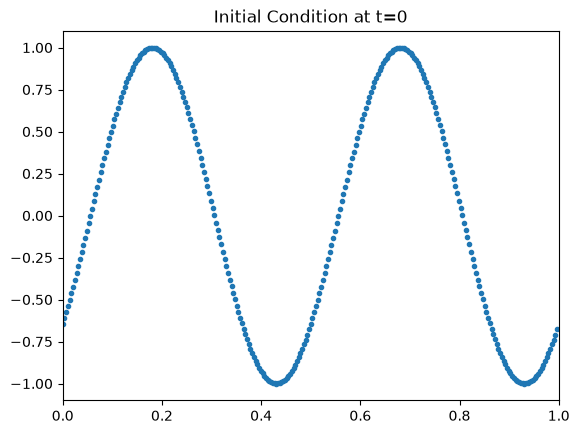

In [11]:
global_x = dv.pull("global_x", targets=dv_main)
global_T0 = dv.pull("global_T0", targets=dv_main)
L = dv.pull("L", targets=dv_main)
plt.plot(global_x, global_T0, ".")
plt.xlim(0.0, L)
plt.title("Initial Condition at t=0")

<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>6.</b> Read and run the below code. It gives an error. What is the problem?<br>
<b>7.</b> One solution to this problem is to extend the arrays with additional elements at the boundary, so called <b><font color="green">halo points (or ghost cells)</font></b>. Define the method <tt>add_halo_points()</tt> that adds a halo point at the beginning and end of an array.
<code>
def add_halo_points(f):
    """Adds halo points to an array on each end (call only once before timeloop)"""
    nan = np.array( [np.nan] )
    return np.concatenate( (nan, f, nan) )
</code>
Try this method out on a short numpy array you create to see its effect.<br>
<b>8.</b> Extend the temperature field <tt>T</tt> with halo points right after setting up the initial condition and before entering the timeloop to add halo points to the <tt>T</tt> field.<br>
<b>9.</b> Inside the timeloop, before every call to the <tt>one_timestep()</tt> method which requires the values of the halo-points, the halo points have to be updated with fresh values. Implement the <tt>update_halo()</tt> method.
<code>
def update_halo(f):
    """Update the halo points (call every timestep before accessing halo-points)"""
    # TODO - implement halo-update here
    return f
</code>
Call it first thing inside the timeloop to update the halo points of the field <tt>T</tt>. <i>(Hint: Since this is the sequential version running only on rank 0, you can simply copy the corresponding array elements into the halo points.)</i><br>
<b>10.</b> Finally, you have to adapt the loop over all gridpoints in the <tt>do_one_timestep()</tt> method to exclude the halo points from the iteration (since we only want to update the inner grid points).<br>
<b>11.</b> Run the program and validate your result visually by looking at the resulting plot of the initial condition and final result.<br>
</div>

![Halo Update](img/sequential_halo_update.png)

In [12]:
%%px


def add_halo_points(f):
    """Adds halo points to an array on each end (call only once before timeloop)"""
    nan = np.array([np.nan])
    return np.concatenate((nan, f, nan))


def update_halo(f):
    """Update the halo points (call every timestep before accessing halo-points)"""
    # TODO - implement halo-update here
    f[0:1] = f[-2:-1]
    f[-1:] = f[1:2]
    return f


def do_one_timestep(T, alpha):
    """Integrate one timestep forward in time"""
    T_new = T.copy()
    # TODO - adapt iteration domain to exclude halo points
    for i in range(1, T.size - 1):
        T_new[i] = alpha * T[i - 1] + (1 - 2 * alpha) * T[i] + alpha * T[i + 1]
    return T_new


alpha = 0.125
nt = 5000

if rank == 0:
    T = global_T0.copy()
    T = add_halo_points(T)
    for it in range(nt):
        T = update_halo(T)
        T = do_one_timestep(T, alpha)

(0.0, 1.0)

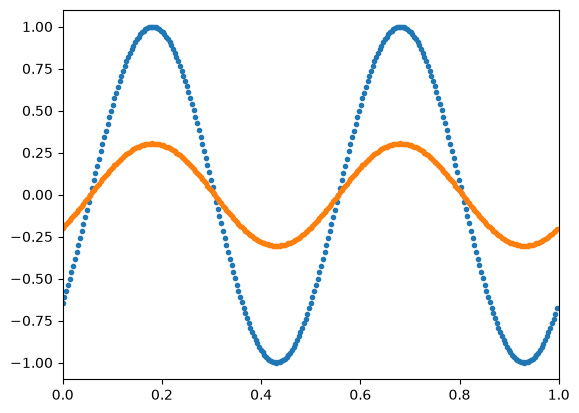

In [13]:
# plot results (from main rank)
global_x = dv.pull("global_x", targets=dv_main)
global_T0 = dv.pull("global_T0", targets=dv_main)
T = dv.pull("T", targets=dv_main)
L = dv.pull("L", targets=dv_main)
plt.plot(global_x, global_T0, ".")
plt.plot(global_x, T[1:-1], ".")
plt.xlim(0.0, L)

## Parallel Halo Updates

Now let's do the same thing but in parallel using MPI. Similar to above, we domain decompose the temperature fields and distribute the gridpoints to the different workers in equal chunks. Halo-updates across different MPI ranks are more complicated, because we need to pass messages using MPI containing the data to fill the halo points from one MPI rank to another. Remember, an MPI rank (worker) does not have access to the memory (e.g. the field `T` containing the temperature) of another MPI rank (worker). This is what the Message Passing Interface (MPI) has been designed for.

![halo points](img/parallel_halo_update.png)

Let's first start with the domain-decomposition and by distributing the initial condition `global_T0` to the subdomains of the MPI ranks (workers). We can use the `Scatter()` operation again. If you want to check the segments on each MPI rank (worker), you can simply add a cell below and run `plt.plot(T0)` to get a plot of the initial condition on the subdomain of each rank.

In [14]:
%%px

# domain-decompose the initial condition for the temperature field T across all MPI ranks (using Scatter)
assert (
    global_nx % num_ranks == 0
), "The length nx must be evenly divisible by the number of MPI ranks"
nx = global_nx // num_ranks

T0 = np.empty(nx)
if rank == 0:
    print(
        "Decomposing array global_T0 of shape {} to {} subdomains T0 of shape {}".format(
            global_T0.shape, num_ranks, T0.shape
        )
    )
else:
    global_T0 = None
comm.Scatter(global_T0, T0, root=0)

[stdout:3] Decomposing array global_T0 of shape (288,) to 12 subdomains T0 of shape (24,)


Out[1:12]: [<matplotlib.lines.Line2D at 0x400042687620>]

Out[6:12]: [<matplotlib.lines.Line2D at 0x400033d37620>]

Out[0:12]: [<matplotlib.lines.Line2D at 0x4000546a3620>]

Out[9:12]: [<matplotlib.lines.Line2D at 0x4000660e7620>]

Out[2:12]: [<matplotlib.lines.Line2D at 0x400045537620>]

...

Out[7:12]: [<matplotlib.lines.Line2D at 0x400048f17620>]

Out[10:12]: [<matplotlib.lines.Line2D at 0x400041d37620>]

Out[11:12]: [<matplotlib.lines.Line2D at 0x40005d543620>]

Out[3:12]: [<matplotlib.lines.Line2D at 0x4000505d41a0>]

[output:5]

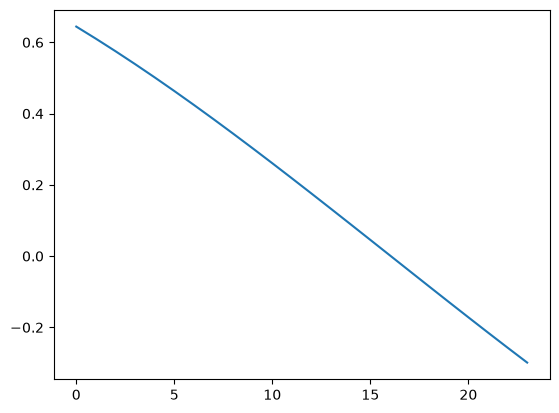

[output:2]

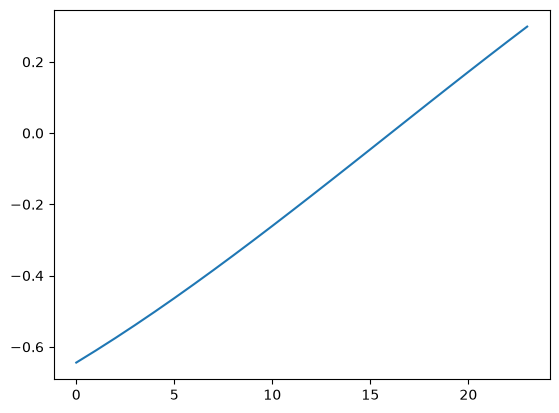

[output:10]

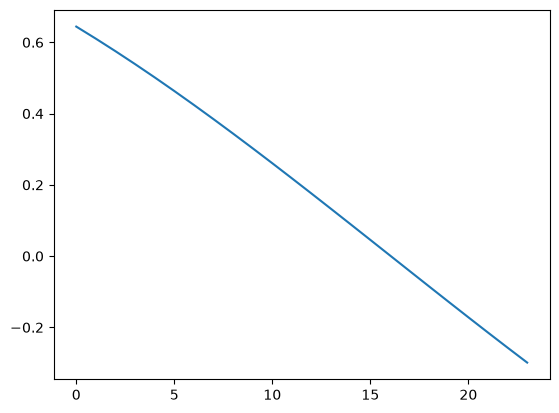

[output:6]

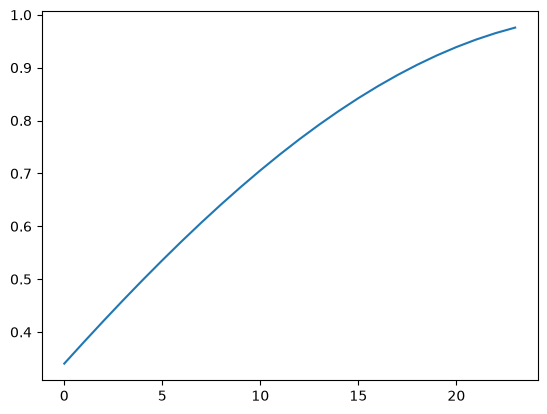

[output:3]

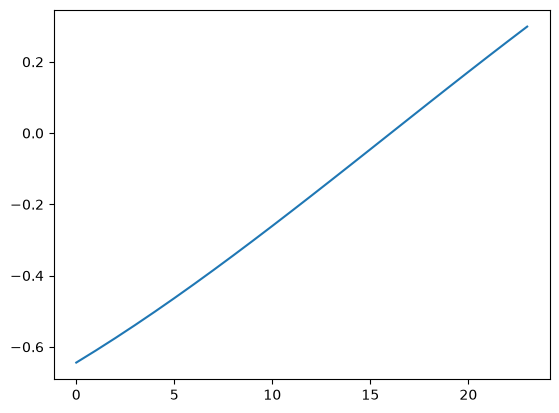

[output:0]

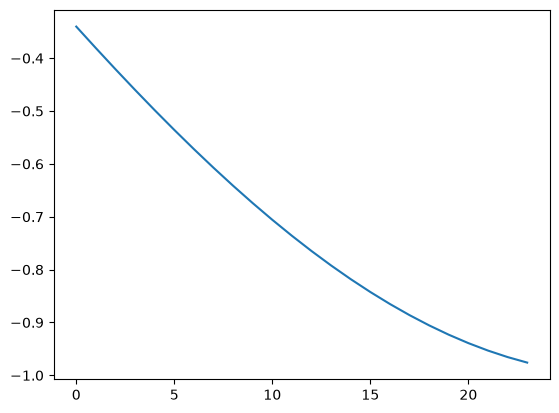

[output:7]

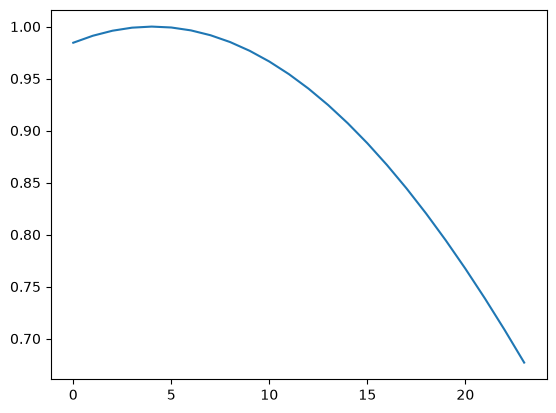

[output:4]

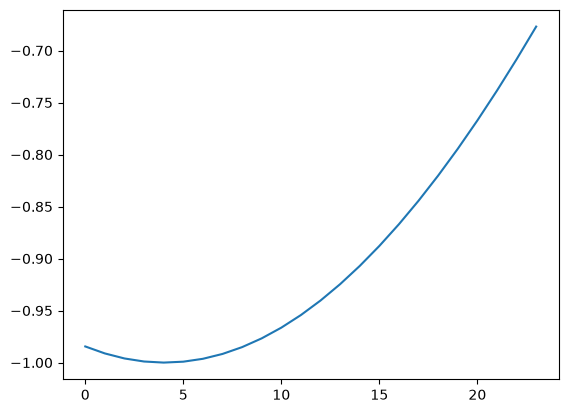

[output:1]

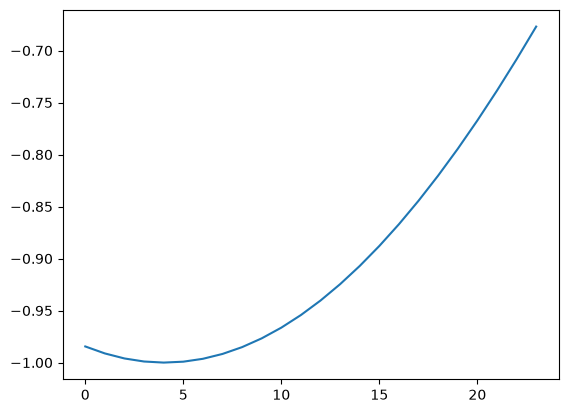

[output:9]

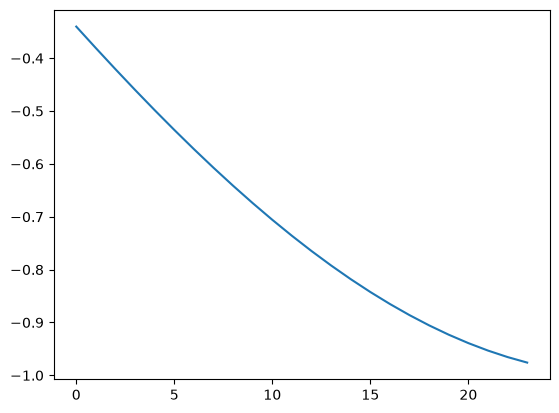

[output:11]

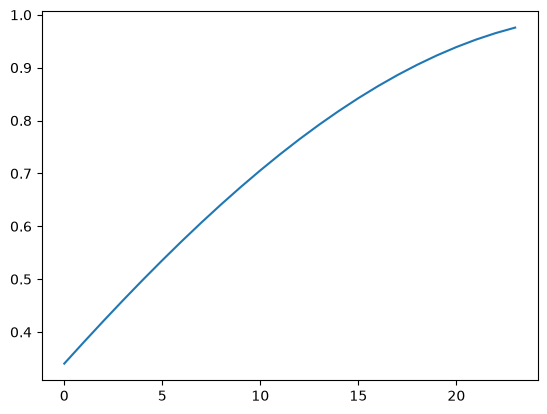

[output:8]

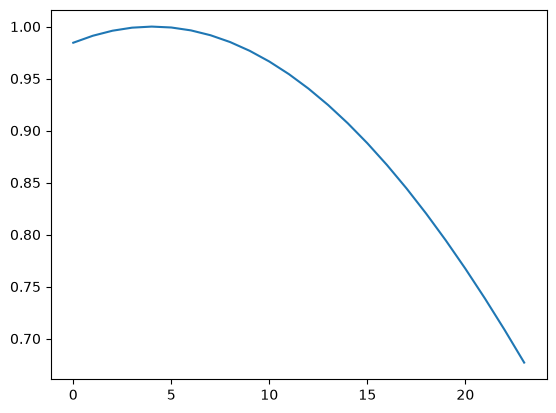

In [15]:
%%px
import matplotlib.pyplot as plt
plt.plot(T0)

Now we're all set and we can start integrating the heat equation on the individual MPI ranks (workers). But we first need to implement a new halo-update method which exchanges messages with neighboring ranks to update the halo-points...

<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>12.</b> Run the program below using the sequential halo-update method you have implemented above. Look at the visualization (next cell). Do you understand what is going on?<br>
<b>13.</b> Insert a new <tt>update_halo()</tt> method (which currently does nothing) into the code cell below.
<code>
def update_halo(f):
    """Update the halo points (call every timestep before accessing halo-points)"""
    # TODO - Implement halo-update using MPI message passing
    # left_rank = ...
    # right_rank = ...
    # comm.Send( ...
    # ...
    return f
</code>
Run the program again and plot the results. Do you understand what is going on?<br>
<b>14.</b> In order for the halo-updates to work correctly, each rank needs to send a temperature value to its left and right neighbors to fill the halo points. The first step is to compute the rank ID of the left and right neighbors. <i>(Hint: Be careful about the cyclic boundary conditions!)</i><br>
<b>15.</b> Now send a message to the left neighbor with the correct information to fill its halo. Implement a matching receive to receive the message from the right neighbor. Use a matching tag for this send/receive pair.<br>
<b>16.</b> Implement a send to the right neighbor and matching receive from the left neighbor as well.<br>
<b>17.</b> Test your implementation of the <code>update_halo()</code> method using an array with 3 gridpoints filled with the rank number.
<code>
f = np.array( [1. * rank]*3 )
print("On rank {} before halo update f is {}".format(rank, f))
f = update_halo(f)
print("On rank {} after halo update f is {}".format(rank, f))
</code>
Make sure the cyclic boundary conditions also work as expected.<br>
<b>18.</b> If everything seems to work correctly, rerun the heat diffusion and check that your results are the same as for the sequential implementation.<br>
<b>19. (Bonus)</b> Implement a couple of different communication strategies for the halo-update after taking a look at <a href="http://wgropp.cs.illinois.edu/courses/cs598-s15/lectures/lecture25.pdf">this presentation</a><br>
</div>

In [16]:
%%px


def update_halo(f):
    """Update the halo points (call every timestep before accessing halo-points)"""

    rank_left = (rank - 1) % num_ranks
    rank_right = (rank + 1) % num_ranks

    strategy = "sendrecv"

    if strategy == "deadlock":
        # send to left, receive from right
        comm.Send(f[1:2], dest=rank_left, tag=120)
        comm.Recv(f[-1:], source=rank_right, tag=120)
        # send to right, receive from left
        comm.Send(f[-2:-1], dest=rank_right, tag=110)
        comm.Recv(f[0:1], source=rank_left, tag=110)
        

    if strategy == "sendrecv":
        # send to left, receive from right
        comm.Sendrecv(sendbuf=f[1:2], dest=rank_left, sendtag=120,
                      recvbuf=f[-1:], source=rank_right, recvtag=120)
        # send to right, receive from left
        comm.Sendrecv(sendbuf=f[-2:-1], dest=rank_right, sendtag=110,
                     recvbuf=f[0:1], source=rank_left, recvtag=110)      

    if strategy == "isendrecv":
        # non-blocking send, blocking receive
        req_left = comm.Isend(f[1:2], dest=rank_left, tag=120)
        req_right = comm.Isend(f[-2:-1], dest=rank_right, tag=110)
        comm.Recv(f[-1:], source=rank_right, tag=120)
        comm.Recv(f[0:1], source=rank_left, tag=110)
        req_left.wait()
        req_right.wait()

    if strategy == "irecvsend":
        # non-blocking receive, blocking send
        req_left = comm.Irecv(f[0:1], source=rank_left, tag=110)
        req_right = comm.Irecv(f[-1:], source=rank_right, tag=120)
        comm.Send(f[-2:-1], dest=rank_right, tag=110)
        comm.Send(f[1:2], dest=rank_left, tag=120)
        req_left.wait()
        req_right.wait()

    if strategy == "irecvisend":
        # non-blocking receive and send
        recvreq_left = comm.Irecv(f[0:1], source=rank_left, tag=110)
        recvreq_right = comm.Irecv(f[-1:], source=rank_right, tag=120)
        sendreq_right = comm.Isend(f[-2:-1], dest=rank_right, tag=110)
        sendreq_left = comm.Isend(f[1:2], dest=rank_left, tag=120)
        sendreq_left.wait()
        sendreq_right.wait()
        recvreq_left.wait()
        recvreq_right.wait()

    if strategy == "evenodd":
        for evenodd in range(2):
            if rank % 2 == evenodd:
                # send left/right (first from even ranks, then from odd)
                comm.Send(f[1:2], dest=rank_left, tag=120 + evenodd)
                comm.Send(f[-2:-1], dest=rank_right, tag=110 + evenodd)
            else:
                # send right/left (first from even ranks, then from odd)
                comm.Recv(f[-1:], source=rank_right, tag=120 + evenodd)
                comm.Recv(f[0:1], source=rank_left, tag=110 + evenodd)

    return f

In [17]:
%%px

alpha = 0.125
nt = 5000

T = add_halo_points(T0)
for it in range(nt):
    T = update_halo(T)
    T = do_one_timestep(T, alpha)

# gather results and make a visualization
if rank == 0:
    global_T = np.empty_like(global_T0)
else:
    global_T = None
comm.Gather(T[1:-1], global_T, root=0)

(0.0, 1.0)

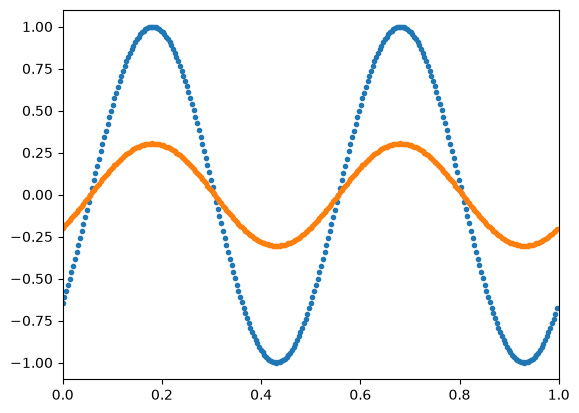

In [18]:
# visualize the results (from main rank)
global_x = dv.pull("global_x", targets=dv_main)
global_T0 = dv.pull("global_T0", targets=dv_main)
global_T = dv.pull("global_T", targets=dv_main)
L = dv.pull("L", targets=dv_main)
plt.plot(global_x, global_T0, ".")
plt.plot(global_x, global_T, ".")
plt.xlim(0.0, L)

## 2-Dimensional Domain Decomposition

The same concepts we have just used to domain-decompose one-dimensional fields can be applied for fields of arbitrary dimensions. In weather and climate models, we typically have 3-dimensional fields `T(i,j,k)` where the indices `i,j,k` correspond to the `x,y,z`-directions.

Since the atmosphere is highly anisotropic, the grid spacing in the vertical is typically much smaller than in the horizontal. For example, in [COSMO-1E](https://www.meteoswiss.admin.ch/weather/warning-and-forecasting-systems/cosmo-forecasting-system.html) the smallest vertical grid spacing is just 20 m whereas the horizontal grid spacing is 1100 m. In order to keep the timestep independent of the small vertical grid spacing, numerical methods in the vertical are often implicit leading to tightly coupled solvers (e.g. tridiagonal solvers) and not to stencil computations. As a result, the computational grid is typically not decomposed in the vertical (`k`) but only in the horizontal (`i,j`).

![cosmo domain decomposition](img/cosmo_decomposition.png)

In the file `partitioner.py` there is a Python class that implements a 2-dimensional domain decomposition of a 3-dimensional domain.

In [19]:
%%px
from partitioner import Partitioner

You can take a look at the `partitioner.py` file and browse the different methods that the partitioner provides. Note that class methods that start with `__method()` are private methods (and you can probably ignore these for the time being).

Let's set up a 3-dimensional domain of size `nz x ny x nx` and decompose it along the `x`- and `y`-directions using the `Partitioner` class. Since our stencils might be wider than the simple example above (heat equation), we will choose to set up our fields with two additional halo points.

In [20]:
%%px

nz = 64
ny = 128
nx = 128
num_halo = 2
global_shape = (nz, ny + 2 * num_halo, nx + 2 * num_halo)

p = Partitioner(comm, [nz, ny, nx], num_halo, periodic=(True, True))

The partitioner has now arranged the `num_ranks` workers in a 2-dimensional grid and computed the subdomain each rank is responsible for. We can create a local field on each MPI rank (worker) using the `p.shape()` method provided by the partitioner.

In [21]:
%%px
f = np.empty(p.shape())
f[:, :, :] = rank

We can now gather the local fields into a global field in order to visualize the rank distribution that the `Partitioner` has chosen for us. The `Partitioner` provides both `gather()` and `scatter()` methods that deal with the details of gathering a domain-decomposed field onto a global field and with distributing a global field onto the workers.

In the plot below, each rank has filled the subdomain it is responsible for (and has a copy of the data in `f`) with its rank number. You can see that rank 0 is in the lower left of the `i,j`-plane and ranks are distributed first left to right and then bottom to top.

In [22]:
%%px
global_f = p.gather(f, root=0)

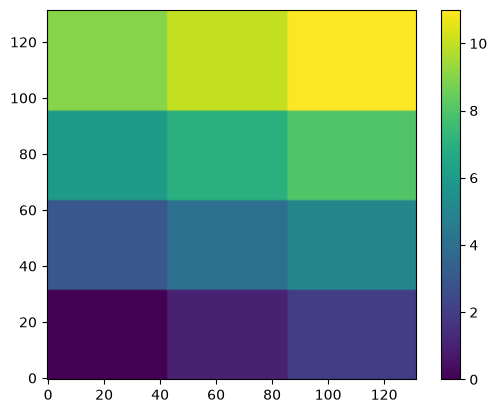

In [23]:
# visualize results (from main rank)
global_f = dv.pull("global_f", targets=dv_main)
plt.imshow(global_f[0, :, :], origin="lower", interpolation=None)
plt.colorbar()

<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
<b>20. (Bonus)</b> Inspect the two-dimensional worker grid chosen by the <code>Partitioner</code>. Restart the notebook with a few different cluster sizes, for example 6, 8, 12, and 16 ranks, and compare <code>p.size()</code>, <code>p.position()</code>, and <code>p.shape()</code>. Which decompositions look best balanced?
</div>

In [24]:
%%px

print(
    "rank {} of {}: worker_grid={} position={} local_shape={}".format(
        rank, num_ranks, p.size(), p.position(), p.shape()
    )
)


[stdout:0] rank 10 of 12: worker_grid=(4, 3) position=(3, 1) local_shape=[64, 36, 47]


[stdout:1] rank 5 of 12: worker_grid=(4, 3) position=(1, 2) local_shape=[64, 36, 46]


[stdout:2] rank 6 of 12: worker_grid=(4, 3) position=(2, 0) local_shape=[64, 36, 47]


[stdout:3] rank 0 of 12: worker_grid=(4, 3) position=(0, 0) local_shape=[64, 36, 47]


[stdout:4] rank 11 of 12: worker_grid=(4, 3) position=(3, 2) local_shape=[64, 36, 46]


...

[stdout:5] rank 3 of 12: worker_grid=(4, 3) position=(1, 0) local_shape=[64, 36, 47]


[stdout:8] rank 8 of 12: worker_grid=(4, 3) position=(2, 2) local_shape=[64, 36, 46]


[stdout:9] rank 4 of 12: worker_grid=(4, 3) position=(1, 1) local_shape=[64, 36, 47]


[stdout:10] rank 9 of 12: worker_grid=(4, 3) position=(3, 0) local_shape=[64, 36, 47]


[stdout:11] rank 7 of 12: worker_grid=(4, 3) position=(2, 1) local_shape=[64, 36, 47]


*Solution discussion:*

The partitioner chooses a factorization that is close to square in the horizontal plane. With the current logic, typical worker grids are `(3, 2)` for 6 ranks, `(4, 2)` for 8 ranks, `(4, 3)` for 12 ranks, and `(4, 4)` for 16 ranks. More square decompositions usually reduce halo surface area relative to local volume, although the exact best choice also depends on the global grid shape.

The partitioner also provides methods for getting the MPI rank of the left / right / top / bottom neighbors, which - as we have seen above - is very useful when implementing a halo-update. We can check whether everything is working, by filling small chunks of our local field `f` with the rank number of our neighbors.

In [25]:
%%px
yc, xc = p.shape()[1] // 2, p.shape()[2] // 2
f[:, :, :] = rank
f[:, yc - 6 : yc - 2, xc - 1 : xc + 2] = (
    p.bottom() if p.bottom() is not None else np.nan
)
f[:, yc + 3 : yc + 7, xc - 1 : xc + 2] = p.top() if p.top() is not None else np.nan
f[:, yc - 1 : yc + 2, xc - 6 : xc - 2] = p.left() if p.left() is not None else np.nan
f[:, yc - 1 : yc + 2, xc + 3 : xc + 7] = p.right() if p.right() is not None else np.nan
global_f = p.gather(f, root=0)

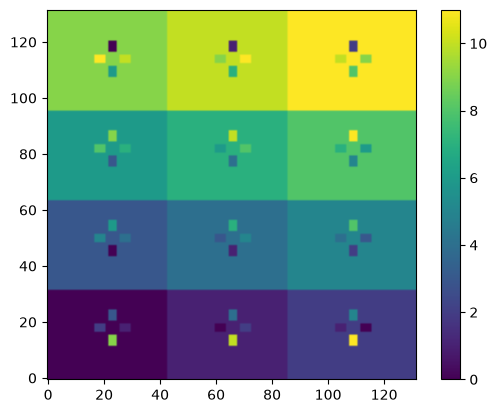

In [26]:
# visualize results (from main rank)
global_f = dv.pull("global_f", targets=dv_main)
plt.imshow(global_f[0, :, :], origin="lower")
plt.colorbar()

<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
<b>21. (Bonus)</b> Write a small test for a two-dimensional halo update. Fill the interior of each local field with the MPI rank number, update the halos, gather the result, and check visually that halo cells contain neighboring rank numbers.
</div>

In [27]:
%%px


def update_halo_2d(field, p):
    """Update horizontal halos using the same two-phase strategy as stencil2d-mpi.py."""
    num_halo = p.num_halo()

    # top/bottom edges, without corners
    bottom_recv = np.empty_like(field[:, 0:num_halo, num_halo:-num_halo])
    top_recv = np.empty_like(field[:, -num_halo:, num_halo:-num_halo])
    reqs_tb = [
        p.comm().Irecv(bottom_recv, source=p.bottom()),
        p.comm().Irecv(top_recv, source=p.top()),
        p.comm().Isend(field[:, -2 * num_halo : -num_halo, num_halo:-num_halo].copy(), dest=p.top()),
        p.comm().Isend(field[:, num_halo : 2 * num_halo, num_halo:-num_halo].copy(), dest=p.bottom()),
    ]
    for req in reqs_tb:
        req.wait()
    field[:, 0:num_halo, num_halo:-num_halo] = bottom_recv
    field[:, -num_halo:, num_halo:-num_halo] = top_recv

    # left/right edges, including corners after the top/bottom update
    left_recv = np.empty_like(field[:, :, 0:num_halo])
    right_recv = np.empty_like(field[:, :, -num_halo:])
    reqs_lr = [
        p.comm().Irecv(left_recv, source=p.left()),
        p.comm().Irecv(right_recv, source=p.right()),
        p.comm().Isend(field[:, :, -2 * num_halo : -num_halo].copy(), dest=p.right()),
        p.comm().Isend(field[:, :, num_halo : 2 * num_halo].copy(), dest=p.left()),
    ]
    for req in reqs_lr:
        req.wait()
    field[:, :, 0:num_halo] = left_recv
    field[:, :, -num_halo:] = right_recv


halo_test = -np.ones(p.shape())
nh = p.num_halo()
halo_test[:, nh:-nh, nh:-nh] = rank
update_halo_2d(halo_test, p)
global_halo_test = p.gather(halo_test, root=0)


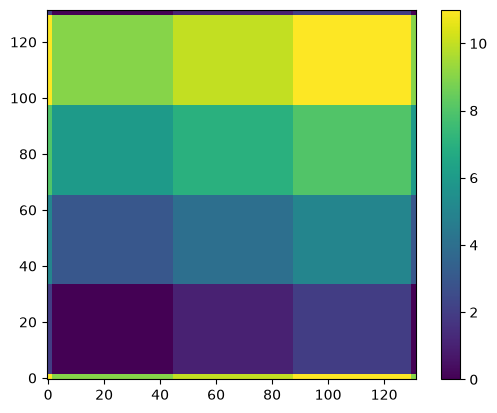

In [28]:
# visualize results (from main rank)
global_halo_test = dv.pull("global_halo_test", targets=dv_main)
plt.imshow(global_halo_test[0, :, :], origin="lower", interpolation="nearest")
plt.colorbar()


*Solution discussion:*

The interior of each subdomain should contain its own rank number. The halo strips should contain the rank numbers of the corresponding left, right, top, and bottom neighbors. The corners are correct only if the left/right exchange is performed after the top/bottom exchange, because the left/right messages include the already-updated corner values.

The `Partitioner` class helps us hide some of the complexities of a 2-dimensional domain decomposition. Namely, it determines the distribution of the MPI ranks onto a 2-dimensional Cartesian grid, it determines the size of each subdomain, it provides us with the MPI rank number of our neighbors, and helps us with scattering and gathering fields.

<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>22.</b> Stop the IPyParallel cluster by running the cell below. There is a Python program named <code>stencil2d.py</code> in the day3 folder which contains a Python version of the stencil2d program we've been working with. Read through the Python program and try to understand the program. You can run it by opening a <code>File &rarr; New &rarr; Terminal</code> and typing the following command
<code>
srun -n 1 -c 1 python stencil2d.py --nx 128 --ny 128 --nz 64 --num_iter 1024 --plot_result True
</code>
which will run the Python script. Inspect the generated <tt>in_field.png</tt> and <tt>out_field.png</tt> to make sure the program is effectively doing what you expect.<br>
<b>23.</b> Create a copy of <code>stencil2d.py</code> and name it <code>stencil2d-mpi.py</code>. Using the partitioner class, parallelize the program using MPI. In a first step, you will only have to modify the <code>main()</code> method. Once you are done with the <code>main()</code> method, you will have to implement a two-dimensional, parallel halo-update. In order to run your program in parallel, you have to increase the number of MPI ranks, for example to 24
<code>
srun -n 24 -c 1 python stencil2d-mpi.py --nx 128 --ny 128 --nz 64 --num_iter 1024 --plot_result True
</code>
For the development phase you can also temporarily reduce the number of iterations, for example to a single iteration.<br>
</div>

<div class="alert alert-block alert-success">
<b>24. (Bonus)</b> The root folder also contains a Fortran version of the MPI stencil program, <code>stencil2d-mpi.F90</code>. Implement the two-dimensional halo exchange in the <code>update_halo()</code> subroutine. The <code>m_partitioner.F90</code> module provides the same information used above: neighbor ranks through <code>left()</code>, <code>right()</code>, <code>top()</code>, and <code>bottom()</code>, the MPI communicator through <code>comm()</code>, the local shape through <code>shape()</code>, and the halo width through <code>num_halo()</code>. Build the program with
<code>
make VERSION=mpi
</code>
and run it with
<code>
srun -n 24 -c 1 ./stencil2d-mpi.x --nx 128 --ny 128 --nz 64 --num_iter 1024
</code>
Start with a small grid while developing. Once the code runs, generate a serial Fortran reference with the same grid and iteration count using <code>make VERSION=orig</code> and <code>srun -n 1 -c 1 ./stencil2d-orig.x --nx 128 --ny 128 --nz 64 --num_iter 1024</code>. Save that reference <code>out_field.dat</code>, then run your MPI version and compare the two fields. The existing <code>validation.sh</code> script validates the Python MPI exercise, not this Fortran bonus.<br>
</div>

In [29]:
rc.close()
%ipcluster stop

IPCluster stopped.


In [30]:
%%bash
srun -n 1 -c 1 python stencil2d.py --nx 128 --ny 128 --nz 64 --num_iter 1024 --plot_result True

Elapsed time for work = 6.533491849899292 s


In [32]:
%%bash
srun -n 24 -c 1 python stencil2d-mpi.py --nx 128 --ny 128 --nz 64 --num_iter 1024 --plot_result True

Elapsed time for work = 0.5318763256072998 s
